# DSW 2023 experiment: EDA, CatBoost CV and a first active learning attempt

Author: Three Outliers (Eduardus Tjitrahardja, Ikhlasul Akmal Hanif, Rahmat Bryan Naufal)


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.metrics import classification_report

import catboost as cb
import os

DATA_DIR = "../data"
DATA_PATH = os.path.join(DATA_DIR, "telco_customer_churn_adapted_v2.xlsx")

In [54]:
df = pd.read_excel(DATA_PATH, sheet_name='Sheet1')
df.head()

,Customer ID,Tenure Months,Location,Device Class,Games Product,Music Product,Education Product,Call Center,Video Product,Use MyApp,Payment Method,Monthly Purchase (Thou. IDR),Churn Label,Longitude,Latitude,CLTV (Predicted Thou. IDR)
0,0,2,Jakarta,Mid End,Yes,Yes,No,No,No,No,Digital Wallet,70.005,Yes,106.816666,-6.2,4210.7
1,1,2,Jakarta,High End,No,No,No,No,No,No,Pulsa,91.910,Yes,106.816666,-6.2,3511.3
2,2,8,Jakarta,High End,No,No,Yes,No,Yes,Yes,Pulsa,129.545,Yes,106.816666,-6.2,6983.6
3,3,28,Jakarta,High End,No,No,Yes,Yes,Yes,Yes,Pulsa,136.240,Yes,106.816666,-6.2,6503.9
4,4,49,Jakarta,High End,No,Yes,Yes,No,Yes,Yes,Debit,134.810,Yes,106.816666,-6.2,6942.0


In [55]:
df.isnull().sum()

Customer ID                     0
Tenure Months                   0
Location                        0
Device Class                    0
Games Product                   0
Music Product                   0
Education Product               0
Call Center                     0
Video Product                   0
Use MyApp                       0
Payment Method                  0
Monthly Purchase (Thou. IDR)    0
Churn Label                     0
Longitude                       0
Latitude                        0
CLTV (Predicted Thou. IDR)      0
dtype: int64

In [56]:
cat_cols = df.drop(["Customer ID", "Churn Label"], axis=1).select_dtypes(include=['object']).columns.to_list()
num_cols = df.drop("Customer ID", axis=1).select_dtypes(include=['number']).columns.to_list()

print("Categorical columns: ", cat_cols)
print("Numerical columns: ", num_cols)

Categorical columns:  ['Location', 'Device Class', 'Games Product', 'Music Product', 'Education Product', 'Call Center', 'Video Product', 'Use MyApp', 'Payment Method']
Numerical columns:  ['Tenure Months', 'Monthly Purchase (Thou. IDR)', 'Longitude', 'Latitude', 'CLTV (Predicted Thou. IDR)']


In [57]:
for col in cat_cols:
    print(f"{col} unique values:", df[col].unique())

Location unique values: ['Jakarta' 'Bandung']
Device Class unique values: ['Mid End' 'High End' 'Low End']
Games Product unique values: ['Yes' 'No' 'No internet service']
Music Product unique values: ['Yes' 'No' 'No internet service']
Education Product unique values: ['No' 'Yes' 'No internet service']
Call Center unique values: ['No' 'Yes']
Video Product unique values: ['No' 'Yes' 'No internet service']
Use MyApp unique values: ['No' 'Yes' 'No internet service']
Payment Method unique values: ['Digital Wallet' 'Pulsa' 'Debit' 'Credit']


In [58]:
df.loc[df["Games Product"] == "No internet service", ["Games Product", "Music Product"]]

,Games Product,Music Product
7,No internet service,No internet service
22,No internet service,No internet service
65,No internet service,No internet service
99,No internet service,No internet service
103,No internet service,No internet service
...,...,...
7023,No internet service,No internet service
7024,No internet service,No internet service
7025,No internet service,No internet service
7033,No internet service,No internet service


In [59]:
def preprocessing(df):
    df = df.copy()
    df.loc[df["Games Product"] != "No internet service", "internet_service"] = 1
    df["internet_service"].fillna(0, inplace=True)
    df["Location"] = df["Location"].map({"Jakarta": 1, "Bandung": 0})
    df["Device Class"] = df["Device Class"].map({"High End": 2, "Mid End": 1, "Low End": 0})
    df["Games Product"] = df["Games Product"].map({"Yes": 1, "No": 0, "No internet service": 0})
    df["Music Product"] = df["Music Product"].map({"Yes": 1, "No": 0, "No internet service": 0})
    df["Education Product"] = df["Education Product"].map({"Yes": 1, "No": 0, "No internet service": 0})
    df["Call Center"] = df["Call Center"].map({"Yes": 1, "No": 0})
    df["Video Product"] = df["Video Product"].map({"Yes": 1, "No": 0, "No internet service": 0})
    df["Use MyApp"] = df["Use MyApp"].map({"Yes": 1, "No": 0, "No internet service": 0})
    df = pd.get_dummies(df, columns=["Payment Method"], prefix="pm")
    return df


In [26]:
df = preprocessing(df)
df.head()

,Customer ID,Tenure Months,Location,Device Class,Games Product,Music Product,Education Product,Call Center,Video Product,Use MyApp,Monthly Purchase (Thou. IDR),Churn Label,Longitude,Latitude,CLTV (Predicted Thou. IDR),internet_service,pm_Credit,pm_Debit,pm_Digital Wallet,pm_Pulsa
0,0,2,1,1,1,1,0,0,0,0,70.005,Yes,106.816666,-6.2,4210.7,1.0,0,0,1,0
1,1,2,1,2,0,0,0,0,0,0,91.910,Yes,106.816666,-6.2,3511.3,1.0,0,0,0,1
2,2,8,1,2,0,0,1,0,1,1,129.545,Yes,106.816666,-6.2,6983.6,1.0,0,0,0,1
3,3,28,1,2,0,0,1,1,1,1,136.240,Yes,106.816666,-6.2,6503.9,1.0,0,0,0,1
4,4,49,1,2,0,1,1,0,1,1,134.810,Yes,106.816666,-6.2,6942.0,1.0,0,1,0,0


In [27]:
df["Churn Label"].value_counts()

No     5174
Yes    1869
Name: Churn Label, dtype: int64

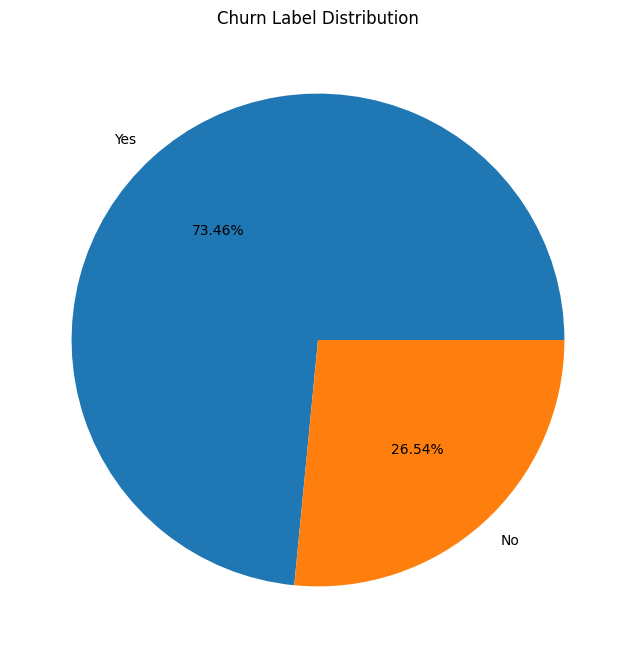

In [30]:
plt.figure(figsize=(10, 8))
plt.pie(df["Churn Label"].value_counts(), labels=df["Churn Label"].unique(), autopct="%.2f%%")
plt.title("Churn Label Distribution")
plt.show()

In [60]:
X = df.drop(["Customer ID", "Churn Label"], axis=1)
y = df["Churn Label"]

TARGET_MAP = {"Yes": 1, "No": 0}
y = y.map(TARGET_MAP)

X.head()

,Tenure Months,Location,Device Class,Games Product,Music Product,Education Product,Call Center,Video Product,Use MyApp,Payment Method,Monthly Purchase (Thou. IDR),Longitude,Latitude,CLTV (Predicted Thou. IDR)
0,2,Jakarta,Mid End,Yes,Yes,No,No,No,No,Digital Wallet,70.005,106.816666,-6.2,4210.7
1,2,Jakarta,High End,No,No,No,No,No,No,Pulsa,91.910,106.816666,-6.2,3511.3
2,8,Jakarta,High End,No,No,Yes,No,Yes,Yes,Pulsa,129.545,106.816666,-6.2,6983.6
3,28,Jakarta,High End,No,No,Yes,Yes,Yes,Yes,Pulsa,136.240,106.816666,-6.2,6503.9
4,49,Jakarta,High End,No,Yes,Yes,No,Yes,Yes,Debit,134.810,106.816666,-6.2,6942.0


In [61]:
y.unique()

array([1, 0], dtype=int64)

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42, test_size=0.2)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5634, 14), (1409, 14), (5634,), (1409,))

In [63]:
cb_model = cb.CatBoostClassifier(random_state=42, verbose=100, task_type="GPU", cat_features=cat_cols)
cb_model.fit(X_train, y_train)

y_pred = cb_model.predict(X_test)

print(classification_report(y_test, y_pred))

Learning rate set to 0.030653
0:	learn: 0.6739989	total: 49ms	remaining: 48.9s
100:	learn: 0.4104186	total: 4.11s	remaining: 36.6s
200:	learn: 0.3983050	total: 8.36s	remaining: 33.2s
300:	learn: 0.3925089	total: 12.4s	remaining: 28.7s
400:	learn: 0.3915335	total: 15.4s	remaining: 23s
500:	learn: 0.3908435	total: 18.5s	remaining: 18.4s
600:	learn: 0.3901265	total: 21.4s	remaining: 14.2s
700:	learn: 0.3892710	total: 24.2s	remaining: 10.3s
800:	learn: 0.3884087	total: 27s	remaining: 6.71s
900:	learn: 0.3878938	total: 29.8s	remaining: 3.27s
999:	learn: 0.3870368	total: 32.7s	remaining: 0us
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [39]:
cb_model = cb.CatBoostClassifier(random_state=42, verbose=False, task_type="GPU")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(cb_model, X, y, cv=cv, scoring="f1")
scores.mean()

0.5533243643436585

In [64]:
cb_model = cb.CatBoostClassifier(random_state=42, verbose=False, task_type="GPU", cat_features=cat_cols)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(cb_model, X, y, cv=cv, scoring="f1")
scores.mean()

0.5583175442481615

In [52]:
cb_model = cb.CatBoostClassifier(random_state=42, verbose=False, task_type="GPU")
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(cb_model, X, y, cv=cv, scoring="f1")
scores.mean()

0.5603982962730079

In [46]:
cb_model = cb.CatBoostClassifier(random_state=42, verbose=False, task_type="GPU")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(cb_model, X_train, y_train, cv=cv, scoring="f1")
scores.mean()

0.5586328883723771

### Active Learning

In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.utils import resample

# Initialize a random forest classifier
classifier = cb.CatBoostClassifier(random_state=42, verbose=False, task_type="GPU")

# Perform active learning and downsampling in a loop
for _ in range(10):  # Repeat the process for a specified number of iterations
    # Train the classifier on the current training set
    classifier.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = classifier.predict(X_test)

    # Evaluate the F1 score
    f1 = f1_score(y_test, y_pred)

    print(f"F1 score: {f1}")

    # Identify the instances in the majority class that are most uncertain (e.g., with low prediction probabilities)
    uncertain_indices = y_train.loc[y_train == 0].index  # Assuming class 0 is the majority class
    uncertain_probabilities = classifier.predict_proba(X_train.loc[uncertain_indices])[:, 1]  # Assuming class 1 is the minority class

    # Choose the top N most uncertain instances to label
    num_instances_to_label = 100  # You can adjust this number based on your needs
    uncertain_instance_indices = uncertain_indices[np.argsort(uncertain_probabilities)[:num_instances_to_label]]

    # Label and add the selected instances to the training set
    X_train = np.vstack([X_train, X_train[uncertain_instance_indices]])
    y_train = np.hstack([y_train, y_train[uncertain_instance_indices]])

    # Downsample the majority class to balance the dataset (optional)
    X_train, y_train = resample(X_train, y_train, n_samples=len(y_train[y_train == 1]), random_state=42)

# Train the final model on the updated training set
classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = classifier.predict(X_test)

# Evaluate the final F1 score
final_f1 = f1_score(y_test, y_pred)

print(f"Final F1 score after active learning and downsampling: {final_f1}")


F1 score: 0.5654135338345865


KeyError: "None of [Int64Index([3736, 5569, 6858, 2046, 4283, 4817, 3006, 4790, 5273, 5246, 5370,\n            4512, 3247, 7038, 6559, 2995, 5674, 2889, 3771, 3868, 6926, 2774,\n            2611, 1953, 4860, 1966, 6884, 5702, 4801, 3184, 2550, 4071, 3194,\n            3135, 3182, 3857, 6062, 4751, 3927, 3106, 6805, 6813, 5221, 5574,\n            2565, 4364, 4687, 2856, 2105, 4331, 6840, 5389, 2234, 5502, 2709,\n            6207, 2072, 3307, 5492, 4305, 3240, 2667, 3739, 3255, 3231, 4565,\n            4545, 5363, 6206, 6883, 6356, 2037, 4814, 4233, 6707, 3773, 5547,\n            3876, 2846, 2583, 1997, 5062, 3129, 6085, 6772, 5598, 2444, 3057,\n            4684, 5414, 6121, 5606, 1978, 3285, 3079, 1975, 5703, 3804, 6250,\n            3272],\n           dtype='int64')] are in the [columns]"

In [49]:
y_train[y_train == 0].index

Int64Index([4626, 4192, 5457, 4717, 4673, 3840, 3823, 2010, 6112, 3535,
            ...
            2810, 5085, 4882, 5292, 6795, 5006, 2964, 6507, 3870, 6017],
           dtype='int64', length=4139)